In [1]:
# ============================================================
# 1) IMPORTS, SEED, CONFIG
# ============================================================

import os

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

import random
import urllib.request
import zipfile
import string
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tqdm import tqdm
from PIL import Image
from pickle import dump, load

from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input,
    Dense,
    LSTM,
    Embedding,
    Dropout,
    Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    print("Deterministic ops enabled.")
except Exception as e:
    print("Could not enable full determinism:", e)

print("Seed fixed:", SEED)

DATA_DIR = "/content/Flickr8k"
IMAGE_ZIP_PATH = os.path.join(DATA_DIR, "Flicker8k_Dataset.zip")
TEXT_ZIP_PATH = os.path.join(DATA_DIR, "Flickr8k_text.zip")
IMAGE_DIR = os.path.join(DATA_DIR, "Flicker8k_Dataset")
MODELS_DIR = "models"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

FORCE_EXTRACT_FEATURES = False

Deterministic ops enabled.
Seed fixed: 42


In [2]:
# ============================================================
# 2) DOWNLOAD AND EXTRACT DATASET
# ============================================================

class DownloadProgressBar(tqdm):
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None:
            self.total = tsize
        self.update(b * bsize - self.n)

def download_url(url, output_path):
    with DownloadProgressBar(
        unit="B",
        unit_scale=True,
        miniters=1,
        desc=url.split("/")[-1]
    ) as progress_bar:
        urllib.request.urlretrieve(
            url,
            filename=output_path,
            reporthook=progress_bar.update_to
        )

print("Downloading Flickr8k Images...")
if not os.path.exists(IMAGE_ZIP_PATH):
    download_url(
        "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip",
        IMAGE_ZIP_PATH
    )
    print("Images downloaded.")
else:
    print("Images already downloaded.")

print("Downloading Flickr8k Text...")
if not os.path.exists(TEXT_ZIP_PATH):
    download_url(
        "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip",
        TEXT_ZIP_PATH
    )
    print("Text downloaded.")
else:
    print("Text already downloaded.")

print("Extracting Images...")
if not os.path.exists(IMAGE_DIR):
    with zipfile.ZipFile(IMAGE_ZIP_PATH, "r") as zip_ref:
        for file in tqdm(zip_ref.namelist(), desc="Extracting images"):
            zip_ref.extract(file, DATA_DIR)
    print("Images extracted.")
else:
    print("Images already extracted.")

print("Extracting Text...")
with zipfile.ZipFile(TEXT_ZIP_PATH, "r") as zip_ref:
    for file in tqdm(zip_ref.namelist(), desc="Extracting text"):
        zip_ref.extract(file, DATA_DIR)
print("Text extracted.")

print("Dataset ready!")

Flickr8k_Dataset.zip: 1.12GB [00:15, 71.4MB/s]                            


Images downloaded.


Flickr8k_text.zip: 2.34MB [00:00, 5.85MB/s]                            


Text downloaded.
Extracting Images...


Extracting images: 100%|██████████| 16186/16186 [00:05<00:00, 2730.47it/s]


Images extracted.
Extracting Text...


Extracting text: 100%|██████████| 10/10 [00:00<00:00, 175.11it/s]

Text extracted.
Dataset ready!


In [3]:
# ============================================================
# 3) FIND DATASET FILES
# ============================================================

print("\nFinding text files...")

token_file = None
train_file = None
val_file = None
test_file = None

for root, _, files in os.walk(DATA_DIR):
    for file in files:
        if file == "Flickr8k.token.txt":
            token_file = os.path.join(root, file)
            print(f"Found token file: {token_file}")

        elif file == "Flickr_8k.trainImages.txt":
            train_file = os.path.join(root, file)
            print(f"Found train file: {train_file}")

        elif file == "Flickr_8k.devImages.txt":
            val_file = os.path.join(root, file)
            print(f"Found validation file: {val_file}")

        elif file == "Flickr_8k.testImages.txt":
            test_file = os.path.join(root, file)
            print(f"Found test file: {test_file}")

if token_file is None:
    raise FileNotFoundError("Flickr8k.token.txt not found!")
if train_file is None:
    raise FileNotFoundError("Flickr_8k.trainImages.txt not found!")
if val_file is None:
    raise FileNotFoundError("Flickr_8k.devImages.txt not found!")
if test_file is None:
    raise FileNotFoundError("Flickr_8k.testImages.txt not found!")


Finding text files...
Found train file: /content/Flickr8k/Flickr_8k.trainImages.txt
Found token file: /content/Flickr8k/Flickr8k.token.txt
Found test file: /content/Flickr8k/Flickr_8k.testImages.txt
Found validation file: /content/Flickr8k/Flickr_8k.devImages.txt


In [4]:
# ============================================================
# 4) TEXT PREPARATION
# ============================================================

def load_doc(filename):
    with open(filename, "r", encoding="utf-8") as file:
        text = file.read()
    return text

def all_img_captions(filename):
    print("Loading image captions...")

    text = load_doc(filename)
    lines = text.split("\n")
    descriptions = {}

    for line in tqdm(lines, desc="Processing captions"):
        line = line.strip()

        if len(line) == 0 or "\t" not in line:
            continue

        image_part, caption = line.split("\t", 1)
        image_id = image_part.split("#")[0]

        if image_id not in descriptions:
            descriptions[image_id] = []

        descriptions[image_id].append(caption)

    return descriptions

def cleaning_text(captions):
    print("Cleaning text...")

    table = str.maketrans("", "", string.punctuation)

    for image_id, caption_list in tqdm(captions.items(), desc="Cleaning captions"):
        for i, caption in enumerate(caption_list):
            caption = caption.replace("-", " ")
            words = caption.split()
            words = [word.lower() for word in words]
            words = [word.translate(table) for word in words]
            words = [word for word in words if len(word) > 1]
            words = [word for word in words if word.isalpha()]
            caption_list[i] = " ".join(words)

    return captions

def text_vocabulary(descriptions):
    print("Building vocabulary...")
    vocab = set()

    for image_id in tqdm(descriptions.keys(), desc="Building vocabulary"):
        for caption in descriptions[image_id]:
            vocab.update(caption.split())

    return vocab

def save_descriptions(descriptions, filename):
    print("Saving descriptions...")
    lines = []

    for image_id, caption_list in descriptions.items():
        for caption in caption_list:
            lines.append(image_id + "\t" + caption)

    data = "\n".join(lines)

    with open(filename, "w", encoding="utf-8") as file:
        file.write(data)

descriptions = all_img_captions(token_file)
print("Length of descriptions =", len(descriptions))

clean_descriptions = cleaning_text(descriptions)

vocabulary = text_vocabulary(clean_descriptions)
print("Length of vocabulary =", len(vocabulary))

save_descriptions(clean_descriptions, "descriptions.txt")

Loading image captions...


Processing captions: 100%|██████████| 40461/40461 [00:00<00:00, 1074440.54it/s]


Length of descriptions = 8092
Cleaning text...


Cleaning captions: 100%|██████████| 8092/8092 [00:00<00:00, 18287.36it/s]


Building vocabulary...


Building vocabulary: 100%|██████████| 8092/8092 [00:00<00:00, 189399.04it/s]


Length of vocabulary = 8422
Saving descriptions...


In [5]:
# ============================================================
# 5) IMAGE FEATURE EXTRACTION
# ============================================================

def preprocess_xception_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize((299, 299))
    image = np.array(image, dtype=np.float32)
    image = image / 127.5
    image = image - 1.0
    return image

def extract_features(directory, batch_size=64):
    print("Loading Xception model...")
    xception_model = Xception(include_top=False, pooling="avg")

    features = {}

    image_list = sorted([
        name for name in os.listdir(directory)
        if name.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    batch_images = []
    batch_names = []

    print(f"Extracting features from {len(image_list)} images...")

    for image_name in tqdm(image_list, desc="Extracting features"):
        image_path = os.path.join(directory, image_name)
        image = preprocess_xception_image(image_path)

        batch_images.append(image)
        batch_names.append(image_name)

        if len(batch_images) == batch_size:
            batch_array = np.array(batch_images, dtype=np.float32)
            batch_features = xception_model.predict(batch_array, verbose=0)

            for name, feature in zip(batch_names, batch_features):
                features[name] = feature

            batch_images = []
            batch_names = []

    if len(batch_images) > 0:
        batch_array = np.array(batch_images, dtype=np.float32)
        batch_features = xception_model.predict(batch_array, verbose=0)

        for name, feature in zip(batch_names, batch_features):
            features[name] = feature

    return features

if FORCE_EXTRACT_FEATURES or not os.path.exists("features.p"):
    image_features = extract_features(IMAGE_DIR, batch_size=64)
    print("Saving features...")
    dump(image_features, open("features.p", "wb"))
    print("Features saved!")
else:
    print("features.p already exists.")

Loading Xception model...
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Extracting features from 8091 images...


Extracting features: 100%|██████████| 8091/8091 [02:46<00:00, 48.46it/s]


Saving features...
Features saved!


In [6]:
# ============================================================
# 6) LOAD SPLITS AND CLEAN DESCRIPTIONS
# ============================================================

def load_photos(filename):
    text = load_doc(filename)
    photos = [line.strip() for line in text.split("\n") if line.strip()]
    return photos

def load_clean_descriptions(filename, photos):
    print("Loading clean descriptions...")

    text = load_doc(filename)
    descriptions = {}
    photos = set(photos)

    for line in tqdm(text.split("\n"), desc="Loading descriptions"):
        line = line.strip()

        if len(line) == 0:
            continue

        parts = line.split()
        image_id = parts[0]
        image_caption = parts[1:]

        if image_id in photos:
            if image_id not in descriptions:
                descriptions[image_id] = []

            caption = "startseq " + " ".join(image_caption) + " endseq"
            descriptions[image_id].append(caption)

    return descriptions

def load_features(photos):
    all_features = load(open("features.p", "rb"))

    selected_features = {}
    missing = []

    for image_id in photos:
        if image_id in all_features:
            feature = np.asarray(all_features[image_id], dtype=np.float32).squeeze()

            if feature.shape != (2048,):
                raise ValueError(
                    f"Feature shape problem for {image_id}: got {feature.shape}, expected (2048,)"
                )

            selected_features[image_id] = feature
        else:
            missing.append(image_id)

    if len(missing) > 0:
        raise KeyError(f"Missing features for {len(missing)} images. Example: {missing[:5]}")

    return selected_features

train_imgs = load_photos(train_file)
val_imgs = load_photos(val_file)
test_imgs = load_photos(test_file)

train_descriptions = load_clean_descriptions("descriptions.txt", train_imgs)
val_descriptions = load_clean_descriptions("descriptions.txt", val_imgs)
test_descriptions = load_clean_descriptions("descriptions.txt", test_imgs)

train_features = load_features(train_imgs)
val_features = load_features(val_imgs)
test_features = load_features(test_imgs)

Loading clean descriptions...


Loading descriptions: 100%|██████████| 40460/40460 [00:00<00:00, 550457.16it/s]


Loading clean descriptions...


Loading descriptions: 100%|██████████| 40460/40460 [00:00<00:00, 921149.55it/s]


Loading clean descriptions...


Loading descriptions: 100%|██████████| 40460/40460 [00:00<00:00, 866708.58it/s]


In [7]:
# ============================================================
# 7) TOKENIZATION
# ============================================================

def dict_to_list(descriptions):
    all_descriptions = []

    for image_id in descriptions.keys():
        all_descriptions.extend(descriptions[image_id])

    return all_descriptions

def create_tokenizer(descriptions):
    print("Creating tokenizer...")
    description_list = dict_to_list(descriptions)
    tokenizer = Tokenizer(oov_token="unk")
    tokenizer.fit_on_texts(description_list)
    return tokenizer

def calculate_max_length(descriptions):
    description_list = dict_to_list(descriptions)
    return max(len(description.split()) for description in description_list)

tokenizer = create_tokenizer(train_descriptions)
dump(tokenizer, open("tokenizer.p", "wb"))
print("Tokenizer saved!")

max_length_value = calculate_max_length(train_descriptions)
dump(max_length_value, open("max_length.p", "wb"))
print("max_length.p saved!")

vocab_size = len(tokenizer.word_index) + 1

print("Max caption length:", max_length_value)
print("Vocabulary size:", vocab_size)

Creating tokenizer...
Tokenizer saved!
max_length.p saved!
Max caption length: 35
Vocabulary size: 7321


In [8]:
# ============================================================
# 8) BUILD TRAINING SAMPLES
# ============================================================

def build_training_samples(descriptions, features, tokenizer, max_length):
    X1, X2, y = [], [], []

    for image_id, desc_list in tqdm(descriptions.items(), desc="Building samples"):
        feature = features[image_id]

        for desc in desc_list:
            seq = tokenizer.texts_to_sequences([desc])[0]

            for i in range(1, len(seq)):
                in_seq = seq[:i]
                out_seq = seq[i]

                in_seq = pad_sequences([in_seq], maxlen=max_length)[0]

                X1.append(feature)
                X2.append(in_seq)
                y.append(out_seq)

    X1 = np.array(X1, dtype=np.float32)
    X2 = np.array(X2, dtype=np.int32)
    y = np.array(y, dtype=np.int32)

    return X1, X2, y

print("Creating training samples...")
X1_train, X2_train, y_train = build_training_samples(
    train_descriptions, train_features, tokenizer, max_length_value
)

print("Creating validation samples...")
X1_val, X2_val, y_val = build_training_samples(
    val_descriptions, val_features, tokenizer, max_length_value
)

print("Train sample shapes:")
print("X1_train:", X1_train.shape)
print("X2_train:", X2_train.shape)
print("y_train :", y_train.shape)

print("Validation sample shapes:")
print("X1_val:", X1_val.shape)
print("X2_val:", X2_val.shape)
print("y_val :", y_val.shape)

Creating training samples...


Building samples: 100%|██████████| 6000/6000 [00:02<00:00, 2010.53it/s]


Creating validation samples...


Building samples: 100%|██████████| 1000/1000 [00:00<00:00, 1471.88it/s]


Train sample shapes:
X1_train: (307075, 2048)
X2_train: (307075, 35)
y_train : (307075,)
Validation sample shapes:
X1_val: (51734, 2048)
X2_val: (51734, 35)
y_val : (51734,)


In [9]:
# ============================================================
# 9) TF DATASET
# ============================================================

BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices(((X1_train, X2_train), y_train))
val_dataset = tf.data.Dataset.from_tensor_slices(((X1_val, X2_val), y_val))

train_dataset = train_dataset.shuffle(
    buffer_size=min(len(y_train), 100000),
    seed=SEED,
    reshuffle_each_iteration=True
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [10]:
# ============================================================
# 10) MODEL DEFINITION
# ============================================================

def define_model(vocab_size, max_length):
    print("Building model...")

    inputs1 = Input(shape=(2048,), name="image_features")
    fe1 = Dropout(0.4)(inputs1)
    fe2 = Dense(256, activation="relu")(fe1)

    inputs2 = Input(shape=(max_length,), name="text_sequence")
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.4)(se1)
    se3 = LSTM(256, use_cudnn=False)(se2)

    merged = Concatenate()([fe2, se3])
    decoder1 = Dense(256, activation="relu")(merged)
    decoder2 = Dropout(0.3)(decoder1)
    outputs = Dense(vocab_size, activation="softmax")(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=optimizer
    )

    model.summary()
    return model

print("\n" + "=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)
print("Train images:", len(train_imgs))
print("Validation images:", len(val_imgs))
print("Test images:", len(test_imgs))
print("Max caption length:", max_length_value)
print("Vocabulary size:", vocab_size)
print("Train samples:", len(y_train))
print("Validation samples:", len(y_val))
print("=" * 60 + "\n")

tf.keras.backend.clear_session()
model = define_model(vocab_size, max_length_value)


TRAINING CONFIGURATION
Train images: 6000
Validation images: 1000
Test images: 1000
Max caption length: 35
Vocabulary size: 7321
Train samples: 307075
Validation samples: 51734

Building model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_sequence       │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 35, 256)   │  1,874,176 │ text_sequence[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ image_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 35, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 35)        │          0 │ text_sequence[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 7321)      │  1,881,497 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,936,857 (18.83 MB)

 Trainable params: 4,936,857 (18.83 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ============================================================
# 11) TRAINING
# ============================================================

epochs = 20

checkpoint_path = os.path.join(MODELS_DIR, "best_model.keras")

callbacks = [
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

model.save(os.path.join(MODELS_DIR, "last_model.keras"))

print("Training completed.")

if "val_loss" in history.history:
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
    best_val_loss = float(np.min(history.history["val_loss"]))
    print("Best epoch:", best_epoch)
    print("Best validation loss:", best_val_loss)

Epoch 1/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 5.1780
Epoch 1: val_loss improved from None to 4.02777, saving model to models/best_model.keras

Epoch 1: finished saving model to models/best_model.keras
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 133s 107ms/step - loss: 4.5873 - val_loss: 4.0278
Epoch 2/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 3.8144
Epoch 2: val_loss improved from 4.02777 to 3.74889, saving model to models/best_model.keras

Epoch 2: finished saving model to models/best_model.keras
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 142s 108ms/step - loss: 3.7454 - val_loss: 3.7489
Epoch 3/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 3.4638
Epoch 3: val_loss improved from 3.74889 to 3.65706, saving model to models/best_model.keras

Epoch 3: finished saving model to models/best_model.keras
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 131s 109ms/step - loss: 3.4289 - val_loss: 3.6571
Epoch 4/20
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 3.2326
Epoch 4: val_loss impro

In [12]:
# ============================================================
# 12) CAPTION GENERATION FUNCTIONS
# ============================================================

def clean_generated_caption(caption):
    caption = re.sub(r"\b(?:startseq|endseq|start|end|unk)\b", "", caption)
    caption = caption.replace("<start>", "").replace("<end>", "")
    caption = re.sub(r"\s+", " ", caption).strip()
    return caption

def prepare_photo_feature(photo):
    photo = np.asarray(photo, dtype=np.float32).squeeze()

    if photo.shape != (2048,):
        raise ValueError(f"Photo feature shape must be (2048,), got {photo.shape}")

    return photo.reshape(1, 2048)

def is_repetition_bad(seq_words, next_word):
    if len(seq_words) >= 1 and seq_words[-1] == next_word:
        return True

    if len(seq_words) >= 3:
        new_bigram = (seq_words[-1], next_word)

        previous_bigrams = set()
        for i in range(len(seq_words) - 1):
            previous_bigrams.add((seq_words[i], seq_words[i + 1]))

        if new_bigram in previous_bigrams:
            return True

    return False

def generate_desc_greedy(model, tokenizer, index_to_word, photo, max_length):
    photo_input = prepare_photo_feature(photo)

    in_words = ["startseq"]

    forbidden_words = {"startseq", "unk"}
    min_caption_words = 3

    for _ in range(max_length):
        sequence_text = " ".join(in_words)
        sequence = tokenizer.texts_to_sequences([sequence_text])[0]

        sequence = pad_sequences(
            [sequence],
            maxlen=max_length,
            padding="post"
        )

        preds = model.predict([photo_input, sequence], verbose=0)[0]
        sorted_indices = np.argsort(preds)[::-1]

        selected_word = None

        for idx in sorted_indices:
            idx = int(idx)

            if idx == 0:
                continue

            word = index_to_word.get(idx)

            if word is None:
                continue

            if word in forbidden_words:
                continue

            generated_word_count = len(in_words) - 1

            if word == "endseq" and generated_word_count < min_caption_words:
                continue

            if word != "endseq" and is_repetition_bad(in_words, word):
                continue

            selected_word = word
            break

        if selected_word is None:
            break

        in_words.append(selected_word)

        if selected_word == "endseq":
            break

    return clean_generated_caption(" ".join(in_words))

def normalized_beam_score(score, seq_words, alpha=0.7):
    length = max(1, len(seq_words) - 1)
    return score / (length ** alpha)

def generate_desc_beam_search(
    model,
    tokenizer,
    index_to_word,
    photo,
    max_length,
    beam_width=3,
    alpha=0.7
):
    photo_input = prepare_photo_feature(photo)

    start_token = "startseq"
    end_token = "endseq"

    forbidden_words = {"startseq", "unk"}
    min_caption_words = 3

    sequences = [([start_token], 0.0)]
    completed_sequences = []

    for _ in range(max_length):
        all_candidates = []

        for seq_words, score in sequences:
            if seq_words[-1] == end_token:
                completed_sequences.append((seq_words, score))
                continue

            sequence_text = " ".join(seq_words)
            encoded = tokenizer.texts_to_sequences([sequence_text])[0]

            encoded = pad_sequences(
                [encoded],
                maxlen=max_length,
                padding="post"
            )

            preds = model.predict([photo_input, encoded], verbose=0)[0]

            top_k = min(len(preds), beam_width * 8)
            top_indices = np.argsort(preds)[-top_k:][::-1]

            for idx in top_indices:
                idx = int(idx)

                if idx == 0:
                    continue

                word = index_to_word.get(idx)

                if word is None:
                    continue

                if word in forbidden_words:
                    continue

                generated_word_count = len(seq_words) - 1

                if word == end_token and generated_word_count < min_caption_words:
                    continue

                if word != end_token and is_repetition_bad(seq_words, word):
                    continue

                probability = float(preds[idx])

                if probability <= 0:
                    continue

                candidate_words = seq_words + [word]
                candidate_score = score - np.log(probability + 1e-10)

                all_candidates.append((candidate_words, candidate_score))

        if len(all_candidates) == 0:
            break

        ordered = sorted(
            all_candidates,
            key=lambda item: normalized_beam_score(item[1], item[0], alpha=alpha)
        )

        sequences = ordered[:beam_width]

        still_active = [seq for seq, _ in sequences if seq[-1] != end_token]
        if len(still_active) == 0:
            completed_sequences.extend(sequences)
            break

    final_candidates = completed_sequences + sequences

    if len(final_candidates) == 0:
        return ""

    best_seq, best_score = sorted(
        final_candidates,
        key=lambda item: normalized_beam_score(item[1], item[0], alpha=alpha)
    )[0]

    return clean_generated_caption(" ".join(best_seq))


TESTING MODEL ON ONE TEST IMAGE

Test image: 3385593926_d3e9c21170.jpg

Generated Caption - Beam Search:
two dogs play in the snow

Generated Caption - Greedy:
two dogs are running through the snow

Reference Captions:
- the dogs are in the snow in front of fence
- the dogs play on the snow
- two brown dogs playfully fight in the snow
- two brown dogs wrestle in the snow
- two dogs playing in the snow


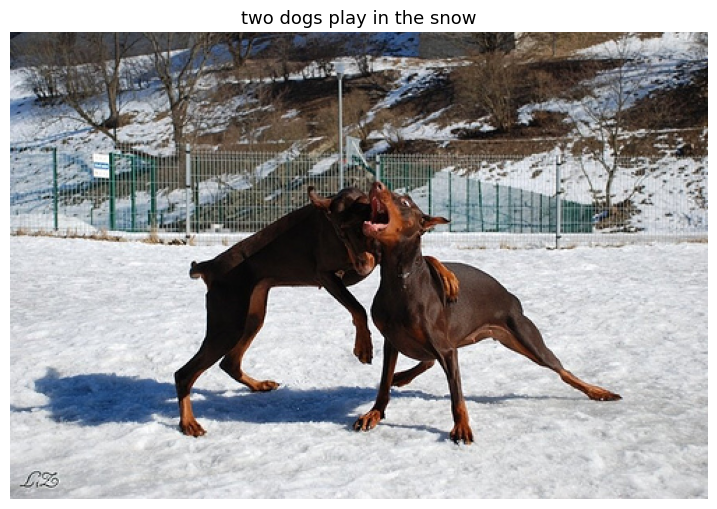

In [13]:
# ============================================================
# 13) TEST MODEL ON ONE IMAGE
# ============================================================

print("\n" + "=" * 60)
print("TESTING MODEL ON ONE TEST IMAGE")
print("=" * 60 + "\n")

max_length = load(open("max_length.p", "rb"))
tokenizer = load(open("tokenizer.p", "rb"))

caption_model = load_model(os.path.join(MODELS_DIR, "best_model.keras"), compile=False)
index_to_word = {index: word for word, index in tokenizer.word_index.items()}

test_image_name = test_imgs[0]
test_image_path = os.path.join(IMAGE_DIR, test_image_name)

print("Test image:", test_image_name)

photo = test_features[test_image_name]

generated_caption_beam = generate_desc_beam_search(
    caption_model,
    tokenizer,
    index_to_word,
    photo,
    max_length,
    beam_width=3
)

generated_caption_greedy = generate_desc_greedy(
    caption_model,
    tokenizer,
    index_to_word,
    photo,
    max_length
)

print("\nGenerated Caption - Beam Search:")
print(generated_caption_beam)

print("\nGenerated Caption - Greedy:")
print(generated_caption_greedy)

print("\nReference Captions:")
for reference_caption in test_descriptions[test_image_name]:
    print("-", clean_generated_caption(reference_caption))

test_image = Image.open(test_image_path).convert("RGB")
plt.figure(figsize=(9, 7))
plt.imshow(test_image)
plt.axis("off")
plt.title(generated_caption_beam, fontsize=13, wrap=True)
plt.show()